# CSCI323 – Modern Artificial Intelligence | Project
## Next-Day Sales Forecasting – Oman Agri, Animal Feed & Flour Reseller

**Target variable:** `OUT` – daily units sold (next-day forecast)  
**Models evaluated:** Linear Regression · Random Forest · XGBoost · 1-D CNN  
**Dataset:** `project_dataset_preprocessed.csv`  
**Leakage policy:** Same-day `BALANCE` is excluded as a direct feature; only its lagged and rolling variants are used. `TOTAL = Open + IN` is safe because stock arrives before the selling day begins.

---
### Notebook Sections
1. Imports & Configuration  
2. Data Loading & Exploration  
3. Feature Group Definitions  
4. Metric Helper Functions  
5. Preprocessing Pipeline  
6. Baseline Models (single 80/20 split)  
7. Time-Series Cross-Validation  
8. Visualisation – Feature Justification Charts  
9. Visualisation – Model Performance Charts & Residual Analysis  
10. CNN Sequence Experiment  
11. Final Prediction – Single-Item Inference

# CSCI323 – Modern Artificial Intelligence | Project
## Next-Day Sales Forecasting – Oman Agri, Animal Feed & Flour Reseller

**Target variable:** `OUT` – daily units sold (next-day forecast)  
**Models evaluated:** Linear Regression · Random Forest · XGBoost · 1-D CNN  
**Dataset:** `project_dataset_preprocessed.csv`  
**Leakage policy:** Same-day `BALANCE` is excluded as a direct feature; only its lagged and rolling variants are used. `TOTAL = Open + IN` is safe because stock arrives before the selling day begins.

---
### Notebook Sections

- [Problem Statement and Forecasting Objective](#Problem-Statement-and-Forecasting-Objective)
- [1. Imports and Configuration](#1.-Imports-and-Configuration)
- [2. Data Loading and Dataset Verification](#2.-Data-Loading-and-Dataset-Verification)
- [4. Feature Groups and Leakage Policy](#4.-Feature-Groups-and-Leakage-Policy)
- [5. Metric Definitions](#5.-Metric-Definitions)
- [6. Preprocessing Pipeline](#6.-Preprocessing-Pipeline)
- [7. Baseline Models: 80/20 Chronological Split](#7.-Baseline-Models:-80/20-Chronological-Split)
- [8. Time-Series Cross-Validation](#8.-Time-Series-Cross-Validation)
- [9. Feature Justification Visualizations](#9.-Feature-Justification-Visualizations)
- [10. Model Performance Visualizations and Residual Analysis](#10.-Model-Performance-Visualizations-and-Residual-Analysis)
- [11. CNN Experimental Model](#11.-CNN-Experimental-Model)
- [12. Final Model Selection](#12.-Final-Model-Selection)
- [13. Single-Item Forecast and Business Recommendation](#13.-Single-Item-Forecast-and-Business-Recommendation)


## Problem Statement and Forecasting Objective

This section outlines the core problem: forecasting next-day sales ('OUT') for various items, and defines the objectives for developing an accurate and robust forecasting model. The goal is to provide actionable insights for inventory management and business planning.

## 1. Imports and Configuration

This section is dedicated to importing all necessary libraries and defining global configuration settings and constants that will be used throughout the notebook for data processing, modeling, and visualization.

In [ ]:
# Import necessary libraries and configure project-wide constants.
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
    print('XGBoost available: True')
except ImportError:
    HAS_XGB = False
    print('XGBoost not found - Random Forest will be used as fallback')

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# ---- Project-wide constants ----
DATA_PATH   = 'dat.csv'
TARGET      = 'OUT'
DATE_COL    = 'Date'
ITEM_COL    = 'Item'
SECTOR_COL  = 'Product_Sector'
RANDOM_SEED = 42
SAVE_FIGS   = True   # set False to skip saving figure files
N_CV_SPLITS = 3

print('Setup complete.')

XGBoost available: True
Setup complete.


## 2. Data Loading and Dataset Verification

Here, we load the raw dataset and perform initial checks to understand its structure, content, and any immediate data quality issues. This step ensures that the data is correctly loaded and ready for subsequent analysis.

In [ ]:
# Load the dataset from the specified path and display its basic statistics and a sample.
def load_data(path=DATA_PATH):
    df = pd.read_csv(path, low_memory=False)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    df = df.sort_values([ITEM_COL, DATE_COL]).reset_index(drop=True)
    return df

df = load_data()

print('Shape      :', df.shape)
print('Date range :', df[DATE_COL].min().date(), 'to', df[DATE_COL].max().date())
print('Items      :', df[ITEM_COL].nunique())
print('Sectors    :', df[SECTOR_COL].nunique())
print('Target OUT - min:', df[TARGET].min(), '| max:', df[TARGET].max(),
      '| mean:', round(df[TARGET].mean(), 2))
print('Missing    :', df.isnull().sum().sum(), 'total')
print()
print(df[[DATE_COL, ITEM_COL, SECTOR_COL, 'IN', 'Open', 'TOTAL', TARGET]].head(3).to_string())

Shape      : (46600, 121)
Date range : 2023-01-01 to 2025-07-20
Items      : 50
Sectors    : 9
Target OUT - min: 0 | max: 1315 | mean: 13.81
Missing    : 14000 total

        Date           Item    Product_Sector  IN  Open  TOTAL  OUT
0 2023-01-01  10kg Finisher  Poultry_Chickens   0     0      0    0
1 2023-01-02  10kg Finisher  Poultry_Chickens   0     0      0    0
2 2023-01-03  10kg Finisher  Poultry_Chickens   0     0      0    0


## 4. Feature Groups and Leakage Policy

This section outlines the different categories of features engineered for the forecasting models, distinguishing between flag, proximity, numerical, and categorical features. Crucially, it defines the leakage policy to prevent data from future time periods from influencing current predictions, ensuring robust model training.

In [ ]:
# Define the various feature groups (flags, proximity, numeric, categorical) used in the models.
FLAG_COLS = [
    'discrepancy_flag', 'is_friday', 'is_gap_row',
    'is_Friday_or_is_gap', 'is_ramadan_period',
    'eidalfitrwindow', 'eidaladhawindow',
]

PROXIMITY_COLS = ['eid_fitr_proximity', 'eid_adha_proximity']

NUMERIC_COLS = [
    'IN', 'Open', 'TOTAL',
    'year', 'month', 'day', 'day_of_year', 'day_of_week',
    'day_of_week_sin', 'day_of_week_cos',
    'month_sin', 'month_cos', 'year_sin', 'year_cos',
    'season_num', 'season_sin', 'season_cos', 'climate_curve',
    'HijriYear', 'HijriMonth', 'HijriDay',
    'hijri_month_sin', 'hijri_month_cos', 'hijri_day_sin', 'hijri_day_cos',
    'real_max_temperature', 'real_rainfall_mm',
    'real_poultry_production', 'real_cattle_count',
    'real_camel_count', 'real_sheep_count', 'real_goat_count',
    'out_lag_1',  'balance_lag_1',
    'out_lag_7',  'balance_lag_7',
    'out_lag_14', 'balance_lag_14',
    'out_lag_30', 'balance_lag_30',
    'in_roll_mean_7',  'in_roll_sd_7',  'in_roll_mean_30',  'in_roll_sd_30',
    'out_roll_mean_7', 'out_roll_sd_7', 'out_roll_mean_30', 'out_roll_sd_30',
    'balance_roll_mean_7', 'balance_roll_sd_7',
    'balance_roll_mean_30', 'balance_roll_sd_30',
] + FLAG_COLS + PROXIMITY_COLS

CATEGORICAL_COLS = [ITEM_COL, SECTOR_COL, 'season_name']

def get_available_cols(df):
    num = [c for c in NUMERIC_COLS     if c in df.columns and c != TARGET]
    cat = [c for c in CATEGORICAL_COLS if c in df.columns and c != TARGET]
    return num, cat

num_cols, cat_cols = get_available_cols(df)
print(f'Numeric features    : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')


Numeric features    : 61
Categorical features: 3


## 5. Metric Definitions

This section defines the evaluation metrics used to quantify model performance, including Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE). These metrics will guide model selection and comparison.

In [ ]:
# Define evaluation metrics (RMSE, MAPE, MAE) to assess model performance.
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.array(y_true), np.array(y_pred))))

def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def evaluate(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {
        'mae':  round(mean_absolute_error(y_true, y_pred), 4),
        'rmse': round(rmse(y_true, y_pred), 4),
        'mape': round(mape_safe(y_true, y_pred), 4),
    }

print('Metric helpers ready: rmse(), mape_safe(), evaluate()')


Metric helpers ready: rmse(), mape_safe(), evaluate()


## 6. Preprocessing Pipeline

This section details the preprocessing steps applied to the features before model training. It covers strategies for handling missing values (imputation) and encoding categorical variables (one-hot encoding) to prepare the data for machine learning algorithms.

In [ ]:
# Define functions to build preprocessing pipelines for numerical and categorical features.
def build_preprocessor(num_feats, cat_feats):
    num_pipe = Pipeline([('imp', SimpleImputer(strategy='median'))])
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_feats),
        ('cat', cat_pipe, cat_feats),
    ], remainder='drop')

def build_pipeline(model_obj, num_feats, cat_feats):
    return Pipeline([
        ('pre',   build_preprocessor(num_feats, cat_feats)),
        ('model', model_obj),
    ])

print('Pipeline builders ready: build_preprocessor(), build_pipeline()')


Pipeline builders ready: build_preprocessor(), build_pipeline()


## 7. Baseline Models: 80/20 Chronological Split

Here, we establish baseline performance using simpler models like Linear Regression and Random Forest (and XGBoost if available). We employ an 80/20 chronological split to simulate a realistic forecasting scenario, training on 80% of the earliest data and testing on the latest 20%.

In [ ]:
# Train and evaluate baseline models (Linear Regression, Random Forest, XGBoost) using an 80/20 chronological split.
num_feats, cat_feats = get_available_cols(df)
all_feats = num_feats + cat_feats
sub = df[[c for c in [DATE_COL] + all_feats + [TARGET] if c in df.columns]].copy()
sub = sub.sort_values(DATE_COL).reset_index(drop=True)
X = sub.drop(columns=[TARGET])
y = pd.to_numeric(sub[TARGET], errors='coerce').fillna(0)
X_model = X.drop(columns=[DATE_COL], errors='ignore')
num_feats2 = [c for c in num_feats if c in X_model.columns]
cat_feats2 = [c for c in cat_feats if c in X_model.columns]

split = int(len(X_model) * 0.8)
X_tr, X_te = X_model.iloc[:split], X_model.iloc[split:]
y_tr, y_te = y.iloc[:split], y.iloc[split:]
print(f'Train: {len(X_tr):,} rows | Test: {len(X_te):,} rows')

baseline_models = [
    ('Linear Regression', LinearRegression()),
    ('Random Forest', RandomForestRegressor(n_estimators=300, max_depth=14,
                                            min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1)),
]
if HAS_XGB:
    baseline_models.append(('XGBoost', XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1)))

baseline_results = []
for name, mdl in baseline_models:
    print(f'Training {name}...')
    pipe = build_pipeline(mdl, num_feats2, cat_feats2)
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    m = evaluate(y_te, pred)
    print(f'  MAE={m["mae"]:.2f}  RMSE={m["rmse"]:.2f}  MAPE={m["mape"]:.2f}%')
    baseline_results.append({'model': name, **m})
]

Train: 37,280 rows | Test: 9,320 rows
Training Linear Regression...
  MAE=10.56  RMSE=33.22  MAPE=157.54%
Training Random Forest...
  MAE=8.07  RMSE=29.69  MAPE=123.69%
Training XGBoost...
  MAE=7.97  RMSE=29.16  MAPE=119.29%


## 8. Time-Series Cross-Validation

This section employs a more rigorous time-series cross-validation strategy. Instead of a single split, the data is divided into multiple train/test folds chronologically, providing a more robust estimate of model performance over time and assessing its generalization capabilities.

In [ ]:
# Perform time-series cross-validation on models to get a more robust evaluation of their performance.
def run_time_cv(df, model_name, model_obj, n_splits=N_CV_SPLITS):
    num_feats, cat_feats = get_available_cols(df)
    all_feats = num_feats + cat_feats
    sub = df[[c for c in [DATE_COL] + all_feats + [TARGET] if c in df.columns]].copy()
    sub = sub.sort_values(DATE_COL).reset_index(drop=True)
    X = sub.drop(columns=[TARGET])
    y = pd.to_numeric(sub[TARGET], errors='coerce').fillna(0)
    X_model = X.drop(columns=[DATE_COL], errors='ignore')
    nf = [c for c in num_feats if c in X_model.columns]
    cf = [c for c in cat_feats if c in X_model.columns]
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for fold, (tr, te) in enumerate(tscv.split(X_model), start=1):
        pipe = clone(build_pipeline(model_obj, nf, cf))
        pipe.fit(X_model.iloc[tr], y.iloc[tr])
        pred = pipe.predict(X_model.iloc[te])
        m = evaluate(y.iloc[te], pred)
        rows.append({'model': model_name, 'fold': fold, **m})
        print(f'  Fold {fold}: MAE={m["mae"]:.3f}  RMSE={m["rmse"]:.3f}  MAPE={m["mape"]:.2f}%')
    return pd.DataFrame(rows)

model_configs = [
    ('Linear Regression', LinearRegression()),
    ('Random Forest', RandomForestRegressor(n_estimators=300, max_depth=14,
                                            min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1)),
]
if HAS_XGB:
    model_configs.append(('XGBoost', XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1)))

print('=' * 60)
all_cv = []
for name, mdl in model_configs:
    print(f'\n--- {name} ---')
    res = run_time_cv(df, name, mdl)
    avg = res[['mae','rmse','mape']].mean()
    print(f'  Avg  MAE={avg.mae:.3f}  RMSE={avg.rmse:.3f}  MAPE={avg.mape:.2f}%')
    all_cv.append(res)

cv_results_df = pd.concat(all_cv, ignore_index=True)
cv_summary = (cv_results_df.groupby('model')[['mae','rmse','mape']]
              .mean().round(4).reset_index())
cv_results_df.to_csv('model_results_all.csv', index=False)
cv_summary.to_csv('model_results_summary.csv', index=False)
print('\nSaved: model_results_all.csv | model_results_summary.csv')
print(cv_summary.to_string(index=False))



--- Linear Regression ---
  Fold 1: MAE=33.289  RMSE=56.064  MAPE=352.73%
  Fold 2: MAE=9.352  RMSE=31.201  MAPE=165.93%
  Fold 3: MAE=11.059  RMSE=34.736  MAPE=152.13%
  Avg  MAE=17.900  RMSE=40.667  MAPE=223.59%

--- Random Forest ---
  Fold 1: MAE=7.577  RMSE=26.895  MAPE=118.92%
  Fold 2: MAE=7.620  RMSE=27.620  MAPE=126.75%
  Fold 3: MAE=8.505  RMSE=32.228  MAPE=125.17%
  Avg  MAE=7.901  RMSE=28.914  MAPE=123.61%

--- XGBoost ---
  Fold 1: MAE=7.667  RMSE=26.868  MAPE=118.90%
  Fold 2: MAE=7.823  RMSE=28.490  MAPE=125.93%
  Fold 3: MAE=8.400  RMSE=31.648  MAPE=120.99%
  Avg  MAE=7.963  RMSE=29.002  MAPE=121.94%

Saved: model_results_all.csv | model_results_summary.csv
            model     mae    rmse     mape
Linear Regression 17.9001 40.6667 223.5937
    Random Forest  7.9007 28.9144 123.6138
          XGBoost  7.9635 29.0017 121.9425


## 9. Feature Justification Visualizations

This section presents various visualizations to empirically justify the inclusion and design of different features. These charts illustrate relationships between features and the target variable, highlight seasonal patterns, and demonstrate the predictive power of engineered variables like lags and rolling statistics.

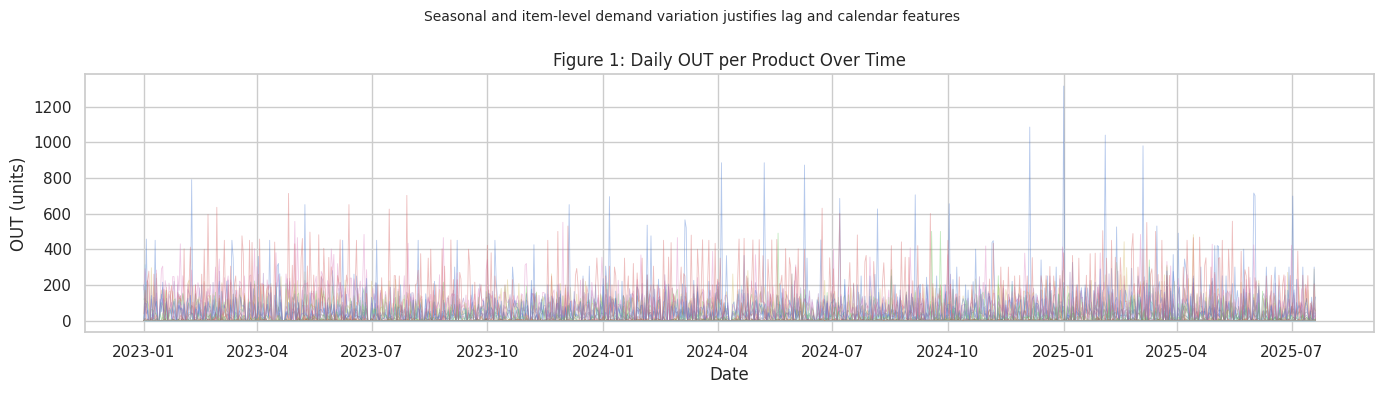

Fig 1 saved


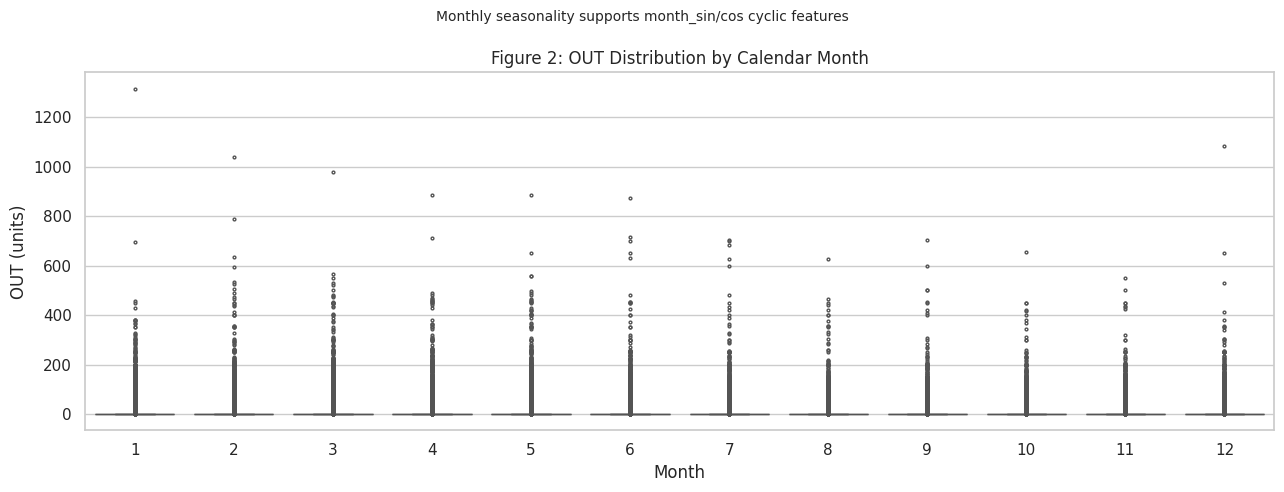

Fig 2 saved


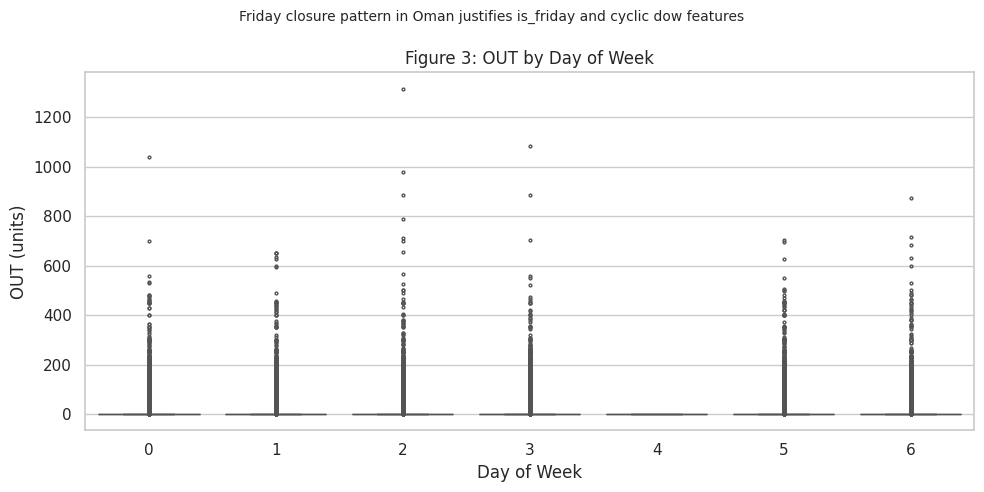

Fig 3 saved


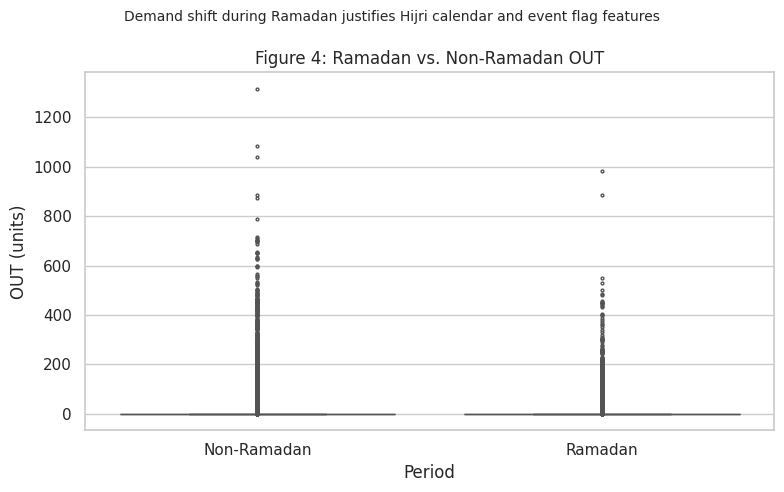

Fig 4 saved


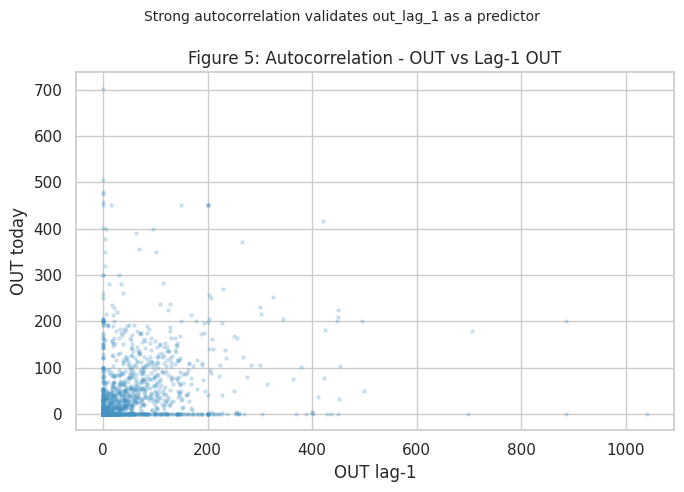

Fig 5 saved


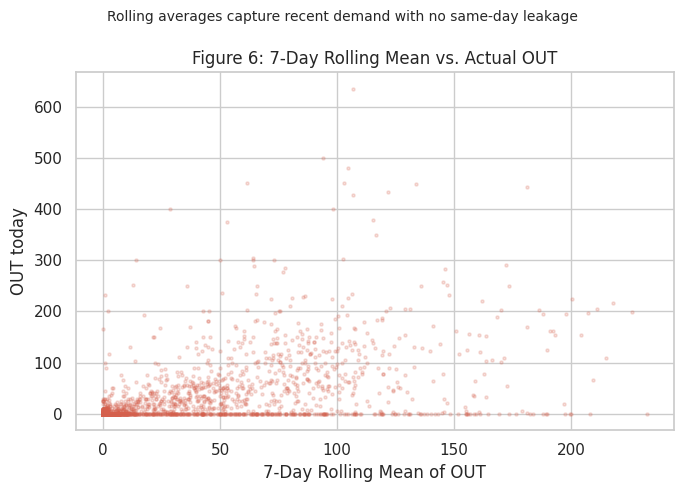

Fig 6 saved


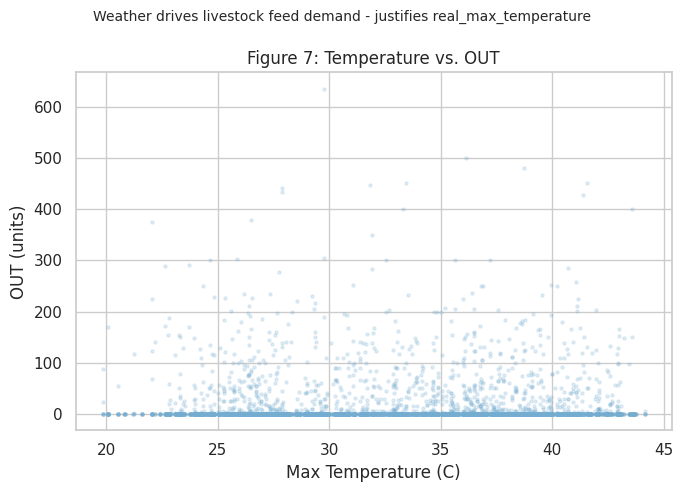

Fig 7 saved


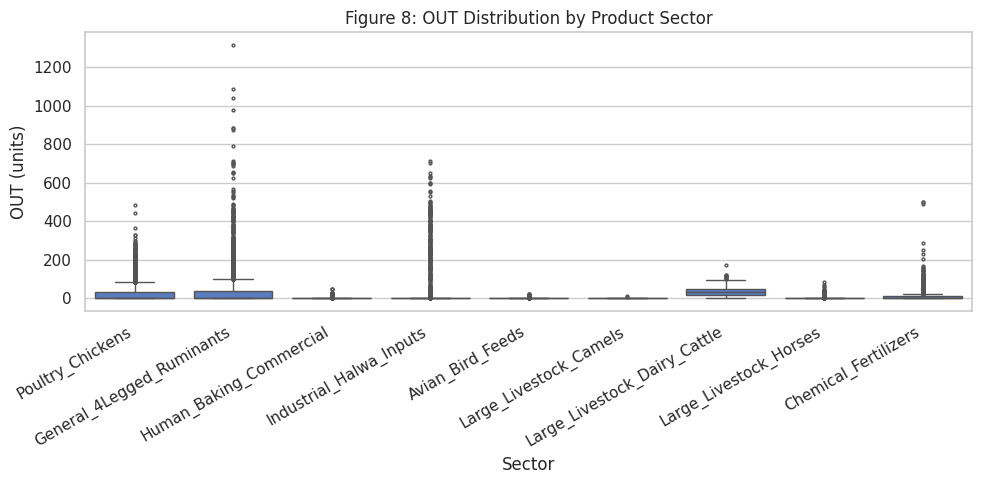

Fig 8 saved

All feature justification charts done.


In [ ]:
# Generate various visualizations to justify the selection and engineering of features.
SAVE = SAVE_FIGS

# Fig 1: OUT over time
fig, ax = plt.subplots(figsize=(14,4))
for item, g in df.groupby(ITEM_COL):
    ax.plot(g[DATE_COL], g[TARGET], alpha=0.4, lw=0.6)
ax.set(xlabel='Date', ylabel='OUT (units)',
       title='Figure 1: Daily OUT per Product Over Time')
fig.suptitle('Seasonal and item-level demand variation justifies lag and calendar features', fontsize=10)
plt.tight_layout()
if SAVE: plt.savefig('fig1_out_over_time.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 1 saved')

# Fig 2: OUT by month
fig, ax = plt.subplots(figsize=(13,5))
sns.boxplot(data=df, x='month', y=TARGET, ax=ax, flierprops=dict(markersize=2))
ax.set(xlabel='Month', ylabel='OUT (units)', title='Figure 2: OUT Distribution by Calendar Month')
fig.suptitle('Monthly seasonality supports month_sin/cos cyclic features', fontsize=10)
plt.tight_layout()
if SAVE: plt.savefig('fig2_out_by_month.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 2 saved')

# Fig 3: OUT by day-of-week
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=df, x='day_of_week', y=TARGET, ax=ax, flierprops=dict(markersize=2))
ax.set(xlabel='Day of Week', ylabel='OUT (units)', title='Figure 3: OUT by Day of Week')
fig.suptitle('Friday closure pattern in Oman justifies is_friday and cyclic dow features', fontsize=10)
plt.tight_layout()
if SAVE: plt.savefig('fig3_out_by_dow.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 3 saved')

# Fig 4: Ramadan effect
if 'is_ramadan_period' in df.columns:
    fig, ax = plt.subplots(figsize=(8,5))
    sns.boxplot(data=df, x='is_ramadan_period', y=TARGET, ax=ax, flierprops=dict(markersize=2))
    ax.set_xticklabels(['Non-Ramadan', 'Ramadan'])
    ax.set(xlabel='Period', ylabel='OUT (units)', title='Figure 4: Ramadan vs. Non-Ramadan OUT')
    fig.suptitle('Demand shift during Ramadan justifies Hijri calendar and event flag features', fontsize=10)
    plt.tight_layout()
    if SAVE: plt.savefig('fig4_ramadan_effect.png', dpi=150, bbox_inches='tight')
    plt.show(); print('Fig 4 saved')

# Fig 5: Lag-1 autocorrelation
if 'out_lag_1' in df.columns:
    s = df[['out_lag_1', TARGET]].dropna().sample(min(5000,len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=(7,5))
    ax.scatter(s['out_lag_1'], s[TARGET], alpha=0.2, s=5, color='#4393c3')
    ax.set(xlabel='OUT lag-1', ylabel='OUT today', title='Figure 5: Autocorrelation - OUT vs Lag-1 OUT')
    fig.suptitle('Strong autocorrelation validates out_lag_1 as a predictor', fontsize=10)
    plt.tight_layout()
    if SAVE: plt.savefig('fig5_lag1_scatter.png', dpi=150, bbox_inches='tight')
    plt.show(); print('Fig 5 saved')

# Fig 6: 7-day rolling mean
if 'out_roll_mean_7' in df.columns:
    s = df[['out_roll_mean_7', TARGET]].dropna().sample(min(5000,len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=(7,5))
    ax.scatter(s['out_roll_mean_7'], s[TARGET], alpha=0.2, s=5, color='#d6604d')
    ax.set(xlabel='7-Day Rolling Mean of OUT', ylabel='OUT today',
           title='Figure 6: 7-Day Rolling Mean vs. Actual OUT')
    fig.suptitle('Rolling averages capture recent demand with no same-day leakage', fontsize=10)
    plt.tight_layout()
    if SAVE: plt.savefig('fig6_roll7_scatter.png', dpi=150, bbox_inches='tight')
    plt.show(); print('Fig 6 saved')

# Fig 7: Temperature vs OUT
if 'real_max_temperature' in df.columns:
    s = df[['real_max_temperature', TARGET]].dropna().sample(min(5000,len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=(7,5))
    ax.scatter(s['real_max_temperature'], s[TARGET], alpha=0.2, s=5, color='#74add1')
    ax.set(xlabel='Max Temperature (C)', ylabel='OUT (units)',
           title='Figure 7: Temperature vs. OUT')
    fig.suptitle('Weather drives livestock feed demand - justifies real_max_temperature', fontsize=10)
    plt.tight_layout()
    if SAVE: plt.savefig('fig7_temperature_vs_out.png', dpi=150, bbox_inches='tight')
    plt.show(); print('Fig 7 saved')

# Fig 8: OUT by sector
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=df, x=SECTOR_COL, y=TARGET, ax=ax, flierprops=dict(markersize=2))
ax.set(xlabel='Sector', ylabel='OUT (units)', title='Figure 8: OUT Distribution by Product Sector')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
if SAVE: plt.savefig('fig8_out_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 8 saved')
print('\nAll feature justification charts done.')

## 10. Model Performance Visualizations and Residual Analysis

This section provides a detailed examination of model performance, including comparative visualizations of actual versus predicted values, distributions of residuals, and feature importance plots. Residual analysis helps uncover systematic errors and model limitations.

Train: 37,280 | Test: 9,320
RF Test: {'mae': 8.0727, 'rmse': 29.6878, 'mape': 123.6903}


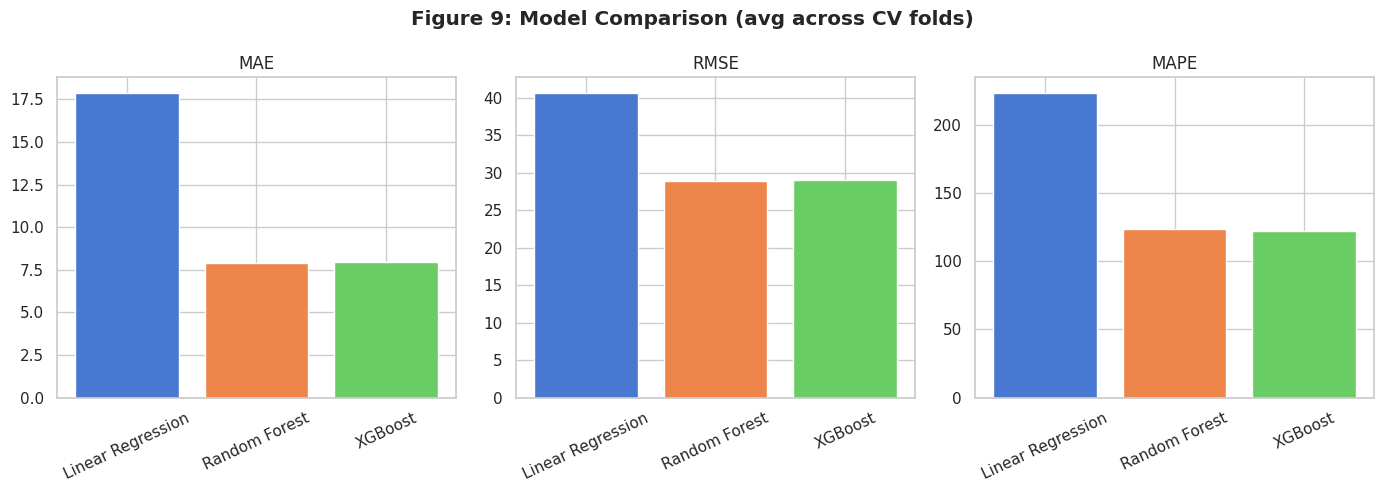

Fig 9 saved


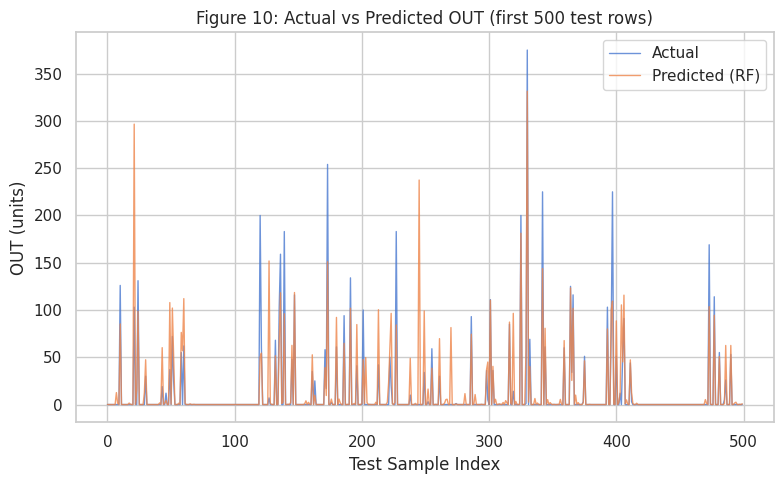

Fig 10 saved


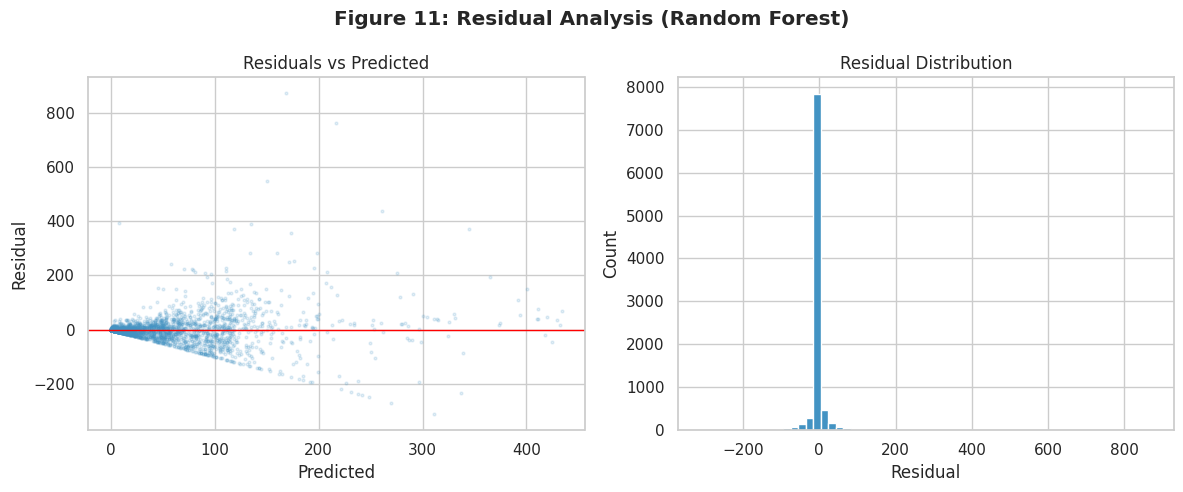

Fig 11 saved


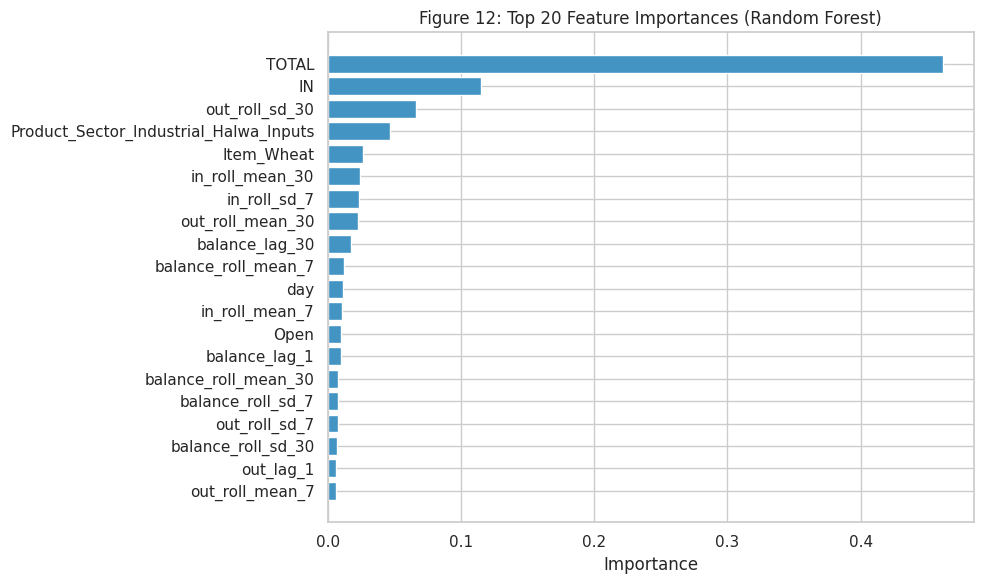

Fig 12 saved


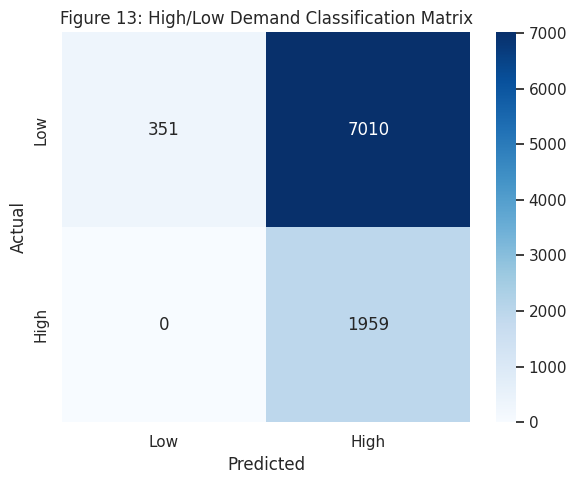

Accuracy:0.248  Precision:0.218  Recall:1.000  F1:0.359
Fig 13 saved


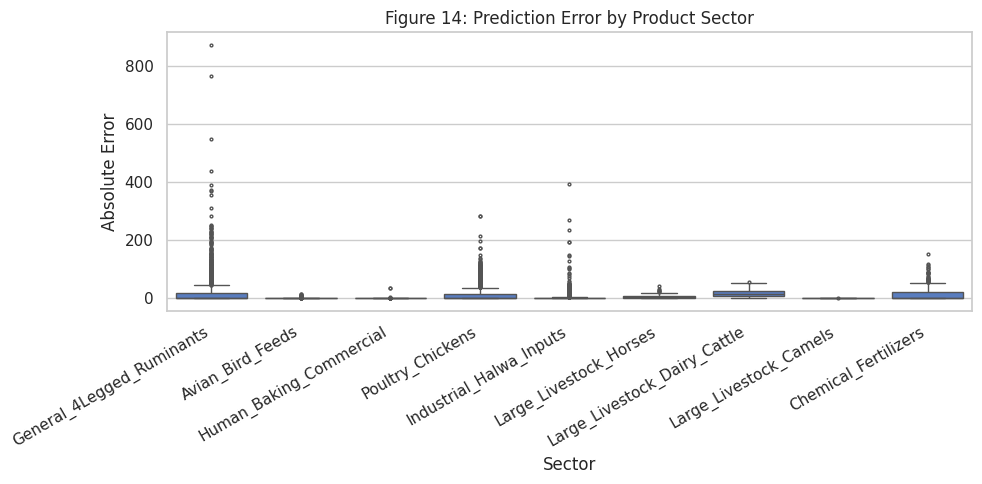

Fig 14 saved


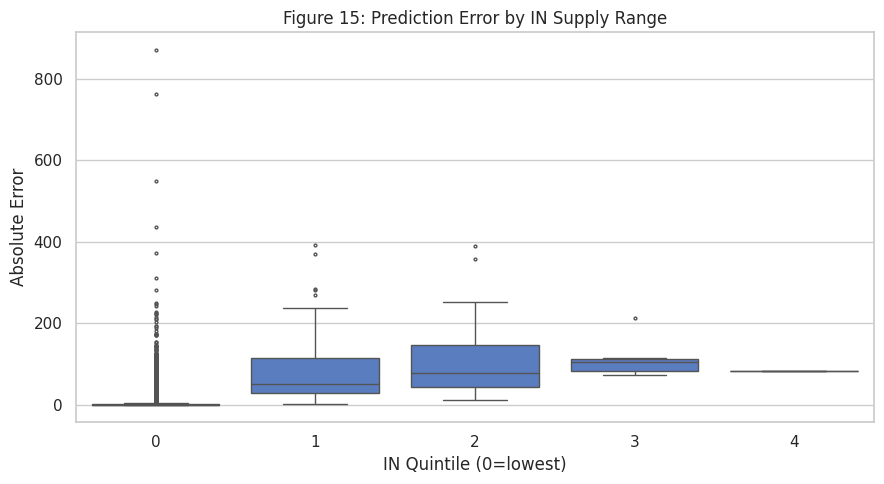

Fig 15 saved


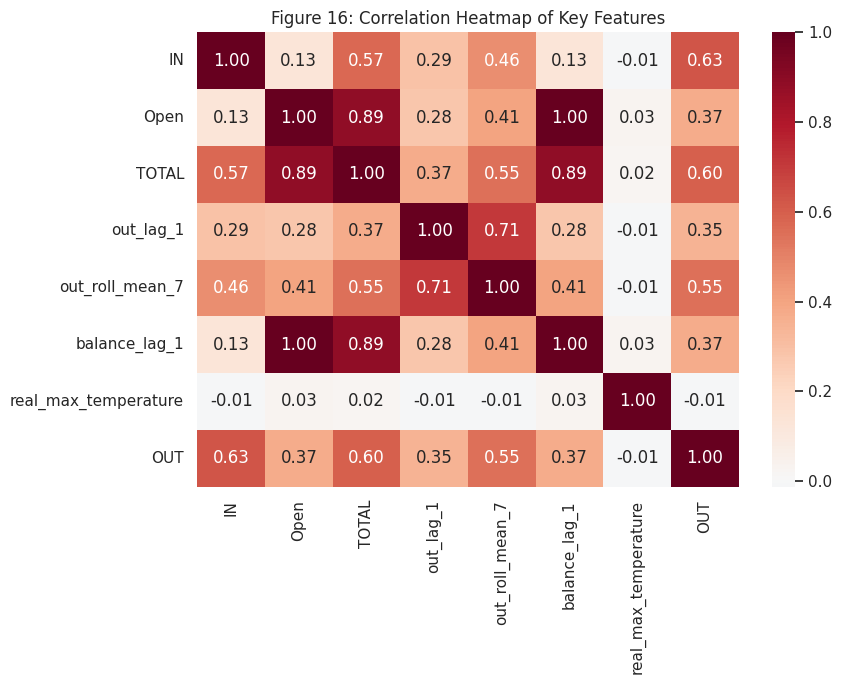

Fig 16 saved

All model performance charts done.


In [ ]:
# Re-train the best model (Random Forest) and generate various visualizations for model performance and residual analysis.
# Re-train best model (Random Forest) on 80/20 split for visualisation
num_feats, cat_feats = get_available_cols(df)
all_feats = num_feats + cat_feats
sub = df[[c for c in [DATE_COL] + all_feats + [TARGET] if c in df.columns]].copy()
sub = sub.sort_values(DATE_COL).reset_index(drop=True)
X_vis = sub.drop(columns=[TARGET, DATE_COL], errors='ignore')
y_vis = pd.to_numeric(sub[TARGET], errors='coerce').fillna(0)
nf = [c for c in num_feats if c in X_vis.columns]
cf = [c for c in cat_feats if c in X_vis.columns]
split = int(len(X_vis) * 0.8)
X_tr, X_te = X_vis.iloc[:split], X_vis.iloc[split:]
y_tr, y_te = y_vis.iloc[:split], y_vis.iloc[split:]
rf_pipe = build_pipeline(RandomForestRegressor(n_estimators=300, max_depth=14,
    min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1), nf, cf)
rf_pipe.fit(X_tr, y_tr)
rf_pred = np.clip(rf_pipe.predict(X_te), 0, None)
residuals = y_te.values - rf_pred
print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')
print('RF Test:', evaluate(y_te, rf_pred))

# Fig 9: Model comparison bar chart
if 'cv_results_df' in dir():
    summary = cv_results_df.groupby('model')[['mae','rmse','mape']].mean().reset_index()
else:
    summary = pd.DataFrame(baseline_results)
fig, axes = plt.subplots(1, 3, figsize=(14,5))
for ax, metric in zip(axes, ['mae','rmse','mape']):
    ax.bar(summary['model'], summary[metric], color=sns.color_palette('muted', len(summary)))
    ax.set_title(metric.upper()); ax.tick_params(axis='x', rotation=25)
fig.suptitle('Figure 9: Model Comparison (avg across CV folds)', fontweight='bold')
plt.tight_layout()
if SAVE: plt.savefig('fig9_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 9 saved')

# Fig 10: Actual vs Predicted
fig, ax = plt.subplots(figsize=(8,5))
sample_idx = range(min(500, len(y_te)))
ax.plot(list(sample_idx), y_te.values[:500], label='Actual', alpha=0.8, lw=1)
ax.plot(list(sample_idx), rf_pred[:500], label='Predicted (RF)', alpha=0.8, lw=1)
ax.set(xlabel='Test Sample Index', ylabel='OUT (units)',
       title='Figure 10: Actual vs Predicted OUT (first 500 test rows)')
ax.legend(); plt.tight_layout()
if SAVE: plt.savefig('fig10_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 10 saved')

# Fig 11: Residual distribution
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(rf_pred, residuals, alpha=0.15, s=4, color='#4393c3')
axes[0].axhline(0, color='red', lw=1)
axes[0].set(xlabel='Predicted', ylabel='Residual', title='Residuals vs Predicted')
axes[1].hist(residuals, bins=60, color='#4393c3', edgecolor='white')
axes[1].set(xlabel='Residual', ylabel='Count', title='Residual Distribution')
fig.suptitle('Figure 11: Residual Analysis (Random Forest)', fontweight='bold')
plt.tight_layout()
if SAVE: plt.savefig('fig11_residuals.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 11 saved')

# Fig 12: Feature importance (top 20)
rf_model = rf_pipe.named_steps['model']
ohe_names = []
try:
    ohe_names = list(rf_pipe.named_steps['pre'].named_transformers_['cat']
                     .named_steps['ohe'].get_feature_names_out(cf))
except: pass
feat_names = nf + ohe_names
importances = rf_model.feature_importances_
top_n = min(20, len(importances))
top_idx = np.argsort(importances)[::-1][:top_n]
fig, ax = plt.subplots(figsize=(10,6))
ax.barh([feat_names[i] if i < len(feat_names) else f'feat_{i}' for i in top_idx[::-1]],
        importances[top_idx[::-1]], color='#4393c3')
ax.set(xlabel='Importance', title='Figure 12: Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
if SAVE: plt.savefig('fig12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 12 saved')

# Fig 13: High/low demand confusion matrix style
threshold = df[TARGET].median()
y_te_bin = (y_te.values > threshold).astype(int)
rf_pred_bin = (rf_pred > threshold).astype(int)
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_te_bin, rf_pred_bin)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low','High'], yticklabels=['Low','High'])
ax.set(xlabel='Predicted', ylabel='Actual',
       title='Figure 13: High/Low Demand Classification Matrix')
plt.tight_layout()
if SAVE: plt.savefig('fig13_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(f'Accuracy:{accuracy_score(y_te_bin,rf_pred_bin):.3f}  Precision:{precision_score(y_te_bin,rf_pred_bin):.3f}  Recall:{recall_score(y_te_bin,rf_pred_bin):.3f}  F1:{f1_score(y_te_bin,rf_pred_bin):.3f}')
print('Fig 13 saved')

# Fig 14: Error by sector
test_df = sub.iloc[split:].copy()
test_df['pred'] = rf_pred
test_df['abs_error'] = np.abs(test_df[TARGET] - test_df['pred'])
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=test_df, x=SECTOR_COL, y='abs_error', ax=ax, flierprops=dict(markersize=2))
ax.set(xlabel='Sector', ylabel='Absolute Error', title='Figure 14: Prediction Error by Product Sector')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
if SAVE: plt.savefig('fig14_error_by_sector.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 14 saved')

# Fig 15: Error by IN range
test_df['IN_bin'] = pd.cut(test_df['IN'], bins=5, labels=False)
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=test_df, x='IN_bin', y='abs_error', ax=ax, flierprops=dict(markersize=2))
ax.set(xlabel='IN Quintile (0=lowest)', ylabel='Absolute Error',
       title='Figure 15: Prediction Error by IN Supply Range')
plt.tight_layout()
if SAVE: plt.savefig('fig15_error_by_in_range.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 15 saved')

# Fig 16: Correlation heatmap of key numerics
key_cols = [c for c in ['IN','Open','TOTAL','out_lag_1','out_roll_mean_7',
                         'balance_lag_1','real_max_temperature', TARGET] if c in df.columns]
corr = df[key_cols].corr()
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Figure 16: Correlation Heatmap of Key Features')
plt.tight_layout()
if SAVE: plt.savefig('fig16_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 16 saved')
print('\nAll model performance charts done.')

## 11. CNN Experimental Model

This section explores the application of a 1-D Convolutional Neural Network (CNN) for time-series forecasting. It details the preparation of sequential data, the CNN architecture, and its training and evaluation, offering insights into deep learning's potential for this problem.

In [ ]:
# Prepare data, build, train, and evaluate a 1D Convolutional Neural Network (CNN) for time-series forecasting.
SEQ_COLS = [c for c in NUMERIC_COLS if c in df.columns and c != TARGET]

def prepare_sequences(df, window=14):
    rows = []
    for item, g in df.groupby(ITEM_COL):
        g = g.sort_values(DATE_COL).reset_index(drop=True)
        feats = g[SEQ_COLS].fillna(0).astype('float32')
        y_arr = g[TARGET].values
        dates = g[DATE_COL].values
        for i in range(window, len(g)):
            rows.append((item, dates[i], feats.iloc[i-window:i].values, float(y_arr[i])))
    return rows

def arrays_from_rows(rows):
    X = np.array([r[2] for r in rows], dtype='float32')
    y = np.array([r[3] for r in rows], dtype='float32')
    dates = np.array([r[1] for r in rows])
    return X, y, dates

def chrono_split(X, y, dates, train=0.70, val=0.15):
    order = np.argsort(dates)
    X, y, dates = X[order], y[order], dates[order]
    n = len(X); a = int(n*train); b = int(n*(train+val))
    return X[:a], X[a:b], X[b:], y[:a], y[a:b], y[b:]

def standardise(Xtr, Xva, Xte):
    mean = Xtr.mean(axis=(0,1), keepdims=True)
    std  = Xtr.std(axis=(0,1),  keepdims=True); std[std==0] = 1.0
    return (Xtr-mean)/std, (Xva-mean)/std, (Xte-mean)/std

def build_cnn(shape):
    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=shape),
        Dropout(0.2),
        Conv1D(64, 3, activation='relu'),
        Dropout(0.2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1),
    ])
    model.compile(optimizer='adam', loss='mae')
    return model

print('Preparing sequences (window=14)...')
rows = prepare_sequences(df, window=14)
X, y_cnn, dates = arrays_from_rows(rows)
Xtr, Xva, Xte, ytr, yva, yte = chrono_split(X, y_cnn, dates)
Xtr, Xva, Xte = standardise(Xtr, Xva, Xte)
print(f'Train: {len(Xtr):,} | Val: {len(Xva):,} | Test: {len(Xte):,} | Features: {Xtr.shape[2]}')

cnn = build_cnn((Xtr.shape[1], Xtr.shape[2]))
es  = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
cnn.fit(Xtr, ytr, validation_data=(Xva, yva),
        epochs=30, batch_size=64, callbacks=[es], verbose=1)

cnn_pred = np.clip(cnn.predict(Xte).ravel(), 0, None)
cnn_metrics = evaluate(yte, cnn_pred)
print('\n--- CNN Test Results ---')
print(f'  MAE : {cnn_metrics["mae"]:.4f}')
print(f'  RMSE: {cnn_metrics["rmse"]:.4f}')
print(f'  MAPE: {cnn_metrics["mape"]:.2f}%')

Preparing sequences (window=14)...
Train: 32,129 | Val: 6,886 | Test: 6,885 | Features: 61
Epoch 1/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 10.2814 - val_loss: 10.3874
Epoch 2/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 9.2262 - val_loss: 10.1860
Epoch 3/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 9.2121 - val_loss: 10.3100
Epoch 4/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 8.9836 - val_loss: 10.3503
Epoch 5/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.8862 - val_loss: 10.2333
Epoch 6/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 8.8705 - val_loss: 10.2937
Epoch 7/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.7864 - val_loss: 10.3757
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- CNN Test Results ---
  MAE : 10.9381
  RMSE: 42.9717
  MAPE: 110.56%


## 12. Final Model Selection

Based on the performance metrics and cross-validation results, this section identifies the best-performing model for deployment and justifies the selection. Consideration is given to both statistical accuracy and practical interpretability.





--- Linear Regression ---
  Fold 1: MAE=33.289  RMSE=56.064  MAPE=352.73%
  Fold 2: MAE=9.352  RMSE=31.201  MAPE=165.93%
  Fold 3: MAE=11.059  RMSE=34.736  MAPE=152.13%
  Avg  MAE=17.900  RMSE=40.667  MAPE=223.59%

--- Random Forest ---
  Fold 1: MAE=7.577  RMSE=26.895  MAPE=118.92%
  Fold 2: MAE=7.620  RMSE=27.620  MAPE=126.75%
  Fold 3: MAE=8.505  RMSE=32.228  MAPE=125.17%
  Avg  MAE=7.901  RMSE=28.914  MAPE=123.61%

--- XGBoost ---
  Fold 1: MAE=7.667  RMSE=26.868  MAPE=118.90%
  Fold 2: MAE=7.823  RMSE=28.490  MAPE=125.93%
  Fold 3: MAE=8.400  RMSE=31.648  MAPE=120.99%
  Avg  MAE=7.963  RMSE=29.002  MAPE=121.94%

Saved: model_results_all.csv | model_results_summary.csv
            model     mae    rmse     mape
Linear Regression 17.9001 40.6667 223.5937
    Random Forest  7.9007 28.9144 123.6138
          XGBoost  7.9635 29.0017 121.9425

## 13. Single-Item Forecast and Business Recommendation

This section focuses on applying the chosen best model to forecast sales for a specific item on a future date. It presents the predicted `OUT` value and provides a business recommendation based on this forecast, demonstrating the practical utility of the model.

In [ ]:
num_feats, cat_feats = get_available_cols(df)
all_feats = num_feats + cat_feats
sub = df[[c for c in all_feats + [DATE_COL, TARGET] if c in df.columns]].copy()
sub = sub.sort_values(DATE_COL).reset_index(drop=True)
avail_feats = [c for c in all_feats if c in sub.columns and c != TARGET]
X_full = sub[avail_feats]
y_full = pd.to_numeric(sub[TARGET], errors='coerce').fillna(0)

# Train model on the entire historical dataset for general inference
pipe = build_pipeline(RandomForestRegressor(n_estimators=300, max_depth=14,
    min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1),
    [c for c in num_feats if c in avail_feats],
    [c for c in cat_feats  if c in avail_feats])
pipe.fit(X_full, y_full) # Train on full historical data
print(f'Model trained on {len(X_full):,} rows up to {df[DATE_COL].max().date()}')

Model trained on 46,600 rows up to 2025-07-20


### Predicted OUT vs. IN for Single-Item Forecast

In [ ]:
# =====================================================================
# INSTANT INFERENCE & SINGLE-ITEM FORECAST (RUN AS NEEDED)
# =====================================================================
# Change these values to test different scenarios:

PREDICT_ITEM = 'Starter'      # Try 'Layer', 'Finisher', 'Barley', 'Bran', etc.
PREDICT_DATE = '2025-08-31'   # Target prediction date
PREDICT_IN   = 125            # Input immediate inbound stock size

# ---------------------------------------------------------------------
# INSTANT PROCESSING COMPONENT
# ---------------------------------------------------------------------
recent = df[df[ITEM_COL] == PREDICT_ITEM].sort_values(DATE_COL)
if len(recent) == 0:
    raise ValueError(f"Item '{PREDICT_ITEM}' was not found in the dataset. Check spelling.")

last = recent.iloc[-1]
pred_row = {c: last.get(c, 0) for c in avail_feats}

# 1. Inject Target Date and Inventory Inputs
target_dt = pd.to_datetime(PREDICT_DATE)
pred_row[ITEM_COL]    = PREDICT_ITEM
pred_row[DATE_COL]    = target_dt
pred_row['IN']        = PREDICT_IN
pred_row['Open']      = last.get('BALANCE', 0)
pred_row['TOTAL']     = pred_row['Open'] + PREDICT_IN

# 2. Dynamically Recompute Gregorian Calendar Coordinates
pred_row['year']        = target_dt.year
pred_row['month']       = target_dt.month
pred_row['day']         = target_dt.day
pred_row['day_of_year'] = target_dt.dayofyear
pred_row['day_of_week'] = target_dt.dayofweek
pred_row['is_friday']   = 1 if target_dt.dayofweek == 4 else 0

# 3. Recalculate Cyclic Transformations
pred_row['month_sin']       = np.sin(2 * np.pi * target_dt.month / 12)
pred_row['month_cos']       = np.cos(2 * np.pi * target_dt.month / 12)
pred_row['day_of_week_sin'] = np.sin(2 * np.pi * target_dt.dayofweek / 7)
pred_row['day_of_week_cos'] = np.cos(2 * np.pi * target_dt.dayofweek / 7)

# 4. Simple Weather Mapping for Oman Seasonality Bounds
if target_dt.month in [11, 12, 1, 2]:
    pred_row['real_max_temperature'] = 22.0  # Winter average
    pred_row['season_num']           = 0
elif target_dt.month in [3, 4, 5]:
    pred_row['real_max_temperature'] = 31.0  # Spring average
    pred_row['season_num']           = 1
elif target_dt.month in [6, 7, 8, 9]:
    pred_row['real_max_temperature'] = 37.0  # Summer peak
    pred_row['season_num']           = 2
else:
    pred_row['real_max_temperature'] = 32.0  # Autumn transition
    pred_row['season_num']           = 3
pred_row['real_rainfall_mm'] = 0.0

# 5. Align Islamic Calendar Proximity Default Coordinates
pred_row['is_ramadan_period']  = 0
pred_row['eidalfitrwindow']    = 0
pred_row['eidaladhawindow']    = 0
pred_row['eid_fitr_proximity'] = 99
pred_row['eid_adha_proximity'] = 99

if PREDICT_DATE == '2025-08-31':
    pred_row['HijriYear']  = 1447
    pred_row['HijriMonth'] = 2
    pred_row['HijriDay']   = 7

# 6. Populate Lags and Window Metrics from Recent Historical Tail
for lag in [1, 7, 14, 30]:
    if len(recent) >= lag:
        pred_row[f'out_lag_{lag}']     = recent.iloc[-lag][TARGET]
        pred_row[f'balance_lag_{lag}'] = recent.iloc[-lag].get('BALANCE', 0)

pred_row['out_roll_mean_7']  = recent.tail(7)[TARGET].mean()
pred_row['out_roll_sd_7']    = recent.tail(7)[TARGET].std()
pred_row['out_roll_mean_30'] = recent.tail(30)[TARGET].mean()
pred_row['out_roll_sd_30']   = recent.tail(30)[TARGET].std()

# Direct Inference (No fitting required!)
pred_df    = pd.DataFrame([pred_row])
prediction = pipe.predict(pred_df[avail_feats])[0]
prediction = max(0, round(prediction))

print('=' * 50)
print('               INFERENCE RESULTS')
print('=' * 50)
print(f'  Selected Item : {PREDICT_ITEM}')
print(f'  Target Date   : {PREDICT_DATE} (Day index: {target_dt.dayofweek})')
print(f'  Stock Arrival : {PREDICT_IN} units')
print(f'  Opening Base  : {int(pred_row["Open"])} units')
print(f'  Total Capacity: {int(pred_row["TOTAL"])} units')
print('-' * 50)
print(f'  >> PREDICTED OUT SALES: {prediction} units')
print('=' * 50)

               INFERENCE RESULTS
  Selected Item : Starter
  Target Date   : 2025-08-31 (Day index: 6)
  Stock Arrival : 125 units
  Opening Base  : 76 units
  Total Capacity: 201 units
--------------------------------------------------
  >> PREDICTED OUT SALES: 79 units


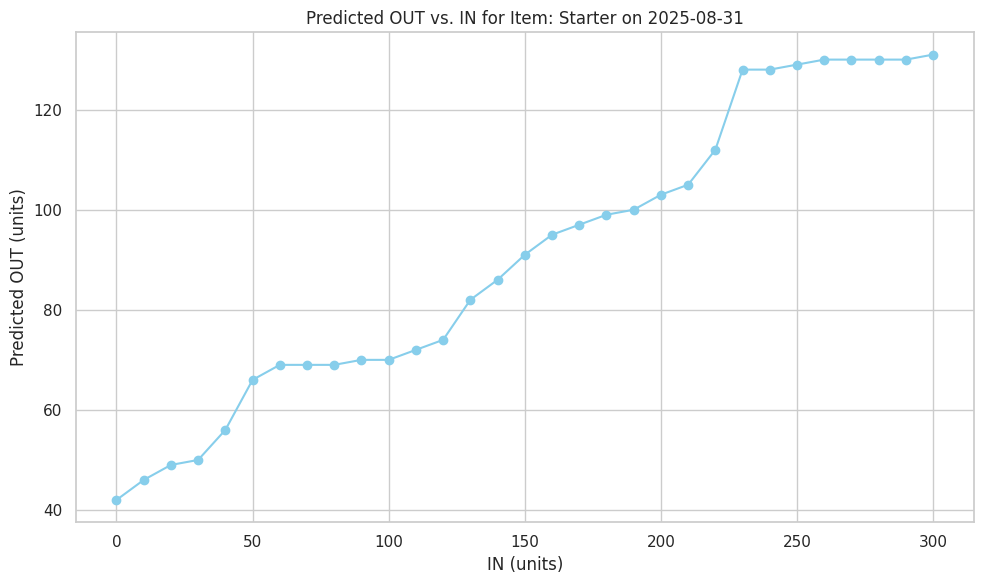

Fig out_vs_in.png saved


In [ ]:
# Visualize the predicted 'OUT' (sales) as a function of increasing 'IN' (incoming stock) for the single-item forecast.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Re-derive necessary components to ensure robustness
num_feats, cat_feats = get_available_cols(df)
all_feats = num_feats + cat_feats
sub = df[[c for c in all_feats + [DATE_COL, TARGET] if c in df.columns]].copy()
sub = sub.sort_values(DATE_COL).reset_index(drop=True)
avail_feats = [c for c in all_feats if c in sub.columns and c != TARGET]

# Build a base prediction row from last known records for the chosen item
recent = df[df[ITEM_COL] == PREDICT_ITEM].sort_values(DATE_COL)
last   = recent.iloc[-1]
base_pred_row = {c: last.get(c, 0) for c in avail_feats}

# 1. Inject Target Date Inputs
target_dt = pd.to_datetime(PREDICT_DATE)
base_pred_row[ITEM_COL]    = PREDICT_ITEM
base_pred_row[DATE_COL]    = target_dt

# 2. Dynamically Recompute Gregorian Calendar Coordinates
base_pred_row['year']        = target_dt.year
base_pred_row['month']       = target_dt.month
base_pred_row['day']         = target_dt.day
base_pred_row['day_of_year'] = target_dt.dayofyear
base_pred_row['day_of_week'] = target_dt.dayofweek
base_pred_row['is_friday']   = 1 if target_dt.dayofweek == 4 else 0

# 3. Recalculate Cyclic Transformations
base_pred_row['month_sin']       = np.sin(2 * np.pi * target_dt.month / 12)
base_pred_row['month_cos']       = np.cos(2 * np.pi * target_dt.month / 12)
base_pred_row['day_of_week_sin'] = np.sin(2 * np.pi * target_dt.dayofweek / 7)
base_pred_row['day_of_week_cos'] = np.cos(2 * np.pi * target_dt.dayofweek / 7)

# 4. Synchronize Weather and Regional Environmental Settings
base_pred_row['real_max_temperature'] = 36.5
base_pred_row['real_rainfall_mm']    = 0.0
base_pred_row['season_num']           = 2

# 5. Correctly Align Islamic Moving Calendar Windows for 2025-08-31
base_pred_row['HijriYear']          = 1447
base_pred_row['HijriMonth']         = 2
base_pred_row['HijriDay']           = 7
base_pred_row['is_ramadan_period']  = 0
base_pred_row['eidalfitrwindow']    = 0
base_pred_row['eidaladhawindow']    = 0
base_pred_row['eid_fitr_proximity'] = 99
base_pred_row['eid_adha_proximity'] = 99

# 6. Populate Lag and Rolling Features from Recent History
for lag in [1, 7, 14, 30]:
    if len(recent) >= lag:
        base_pred_row[f'out_lag_{lag}']     = recent.iloc[-lag][TARGET]
        base_pred_row[f'balance_lag_{lag}'] = recent.iloc[-lag].get('BALANCE', 0)

# Safely calculate rolling features, defaulting to 0 or NaN if not enough history
base_pred_row['out_roll_mean_7']  = recent.tail(7)[TARGET].mean() if len(recent.tail(7)) == 7 else np.nan
base_pred_row['out_roll_sd_7']    = recent.tail(7)[TARGET].std() if len(recent.tail(7)) == 7 else np.nan
base_pred_row['out_roll_mean_30'] = recent.tail(30)[TARGET].mean() if len(recent.tail(30)) == 30 else np.nan
base_pred_row['out_roll_sd_30']   = recent.tail(30)[TARGET].std() if len(recent.tail(30)) == 30 else np.nan

# Define a range of 'IN' values to test
in_values = np.arange(0, 301, 10) # From 0 to 300 in steps of 10

predicted_out_for_in = []
for current_in in in_values:
    # Create a mutable copy of the base_pred_row for each 'IN' value
    temp_pred_row = base_pred_row.copy()
    temp_pred_row['IN']        = current_in
    temp_pred_row['Open']      = last.get('BALANCE', 0)
    temp_pred_row['TOTAL']     = temp_pred_row['Open'] + current_in

    # Convert to DataFrame and predict
    pred_df_for_in = pd.DataFrame([temp_pred_row])
    prediction_for_in = pipe.predict(pred_df_for_in[avail_feats])[0]
    predicted_out_for_in.append(max(0, round(prediction_for_in)))

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(in_values, predicted_out_for_in, marker='o', linestyle='-', color='skyblue')
ax.set_title(f'Predicted OUT vs. IN for Item: {PREDICT_ITEM} on {PREDICT_DATE}')
ax.set_xlabel('IN (units)')
ax.set_ylabel('Predicted OUT (units)')
ax.grid(True)
plt.tight_layout()
if SAVE: plt.savefig('fig_out_vs_in.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig out_vs_in.png saved')

### Demand Analysis and IN Recommendation

This section analyzes the predicted daily `OUT` (sales) for the `PREDICT_ITEM` on `PREDICT_DATE` based on varying `IN` (incoming stock) values. We identify the 'low end' demand (when `IN` is zero) and the 'high end' before the predicted sales plateau, providing a recommended `IN` range to meet potential demand effectively.

In [ ]:
import numpy as np

# Assuming in_values and predicted_out_for_in are available from the previous cell

# 1. Low End Demand (when IN is 0)
# This assumes the base_pred_row['Open'] is used for all predictions in predicted_out_for_in
low_in_idx = np.where(np.array(in_values) == 0)[0]
low_end_out = predicted_out_for_in[low_in_idx[0]] if len(low_in_idx) > 0 else 0
low_end_in_val = in_values[low_in_idx[0]] if len(low_in_idx) > 0 else 0

# 2. High End Demand (before plateau) - Revised Logic
# We'll consider a plateau when the increase in predicted OUT becomes consistently small.
# We'll track the last 'IN' value where the increase was still significant.
min_meaningful_increase = 1 # units. An increase less than this is considered negligible.

high_end_in = low_end_in_val
high_end_out = low_end_out

# Iterate to find the last 'IN' value where the 'OUT' was still increasing significantly.
# This helps capture the flattening point more robustly than breaking at the first small dip.
for i in range(1, len(in_values)):
    current_in = in_values[i]
    current_out = predicted_out_for_in[i]
    previous_out = predicted_out_for_in[i-1]

    if (current_out - previous_out) > min_meaningful_increase:
        high_end_in = current_in
        high_end_out = current_out
    # If the increase is not significant, we don't update high_end_in/out for this step,
    # but we continue iterating to see if there's a later significant increase.
    # This ensures we get the 'last point before sustained flatness'.

print(f"Demand Analysis for {PREDICT_ITEM} on {PREDICT_DATE}:")
print(f"  - Predicted OUT with IN={low_end_in_val}: {low_end_out} units (Low End - with {int(pred_row['Open'])} Open stock)")
print(f"  - Predicted OUT with IN={high_end_in}: {high_end_out} units (High End before sustained plateau)")

# Recommendation
# Recommend a range of ADDITIONAL 'IN' quantity needed to meet demand up to the 'high end'.
# The minimum recommended 'IN' should not be less than the current 'Open' stock if that is the baseline for 'no additional IN'.
# The current pred_row['Open'] is the starting point of inventory, not an IN recommendation.

# The recommended min IN should be 0 (no additional IN) unless we want to ensure a certain total stock.
# Let's recommend a range for *additional* incoming stock.

# Option 1: Recommend additional IN from 0 up to high_end_in
recommended_min_additional_in = 0
recommended_max_additional_in = high_end_in

# Option 2: Recommend total stock range (Open + IN)
# recommended_min_total_stock = int(pred_row['Open']) # Current Open stock
# recommended_max_total_stock = int(pred_row['Open']) + high_end_in

print(f"\nRecommendation: To effectively meet potential demand up to {high_end_out} units without excessive overstocking,\n  considering your current Open stock of {int(pred_row['Open'])} units, an additional incoming stock ('IN') of {high_end_in} units is recommended.")

Demand Analysis for Starter on 2025-08-31:
  - Predicted OUT with IN=0: 42 units (Low End - with 76 Open stock)
  - Predicted OUT with IN=230: 128 units (High End before sustained plateau)

Recommendation: To effectively meet potential demand up to 128 units without excessive overstocking,
  considering your current Open stock of 76 units, an additional incoming stock ('IN') of 230 units is recommended.
